In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Split
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Cargar dataset procesado
credit_df = pd.read_csv("../data/processed/credit_df_processed.csv")
credit_df.head()


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,1,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,0,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,0,1,1


In [2]:
# Variables predictoras
X = credit_df.drop(columns=['loan_status'])

# Variable objetivo
y = credit_df['loan_status']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    max_depth=5
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]


In [4]:
# X sin cibil_score
X_no_cibil = X.drop(columns=['cibil_score'])

# Mismo split, misma semilla
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cibil,
    y,
    test_size=0.2,
    random_state=42
)


In [5]:
rf_no_cibil = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    max_depth=5
)

rf_no_cibil.fit(X_train_nc, y_train_nc)

# Predicciones
y_pred_rf_nc = rf_no_cibil.predict(X_test_nc)
y_prob_rf_nc = rf_no_cibil.predict_proba(X_test_nc)[:, 1]


In [6]:
print("\nComparación Random Forest")
print("Con CIBIL:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nSin CIBIL:")
print(f"Accuracy : {accuracy_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"Precision: {precision_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"Recall   : {recall_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"F1       : {f1_score(y_test_nc, y_pred_rf_nc):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_nc, y_prob_rf_nc):.4f}")



Comparación Random Forest
Con CIBIL:
Accuracy : 0.9707
Precision: 0.9776
Recall   : 0.9757
F1       : 0.9767
ROC-AUC  : 0.9977

Sin CIBIL:
Accuracy : 0.6276
Precision: 0.6276
Recall   : 1.0000
F1       : 0.7712
ROC-AUC  : 0.5837


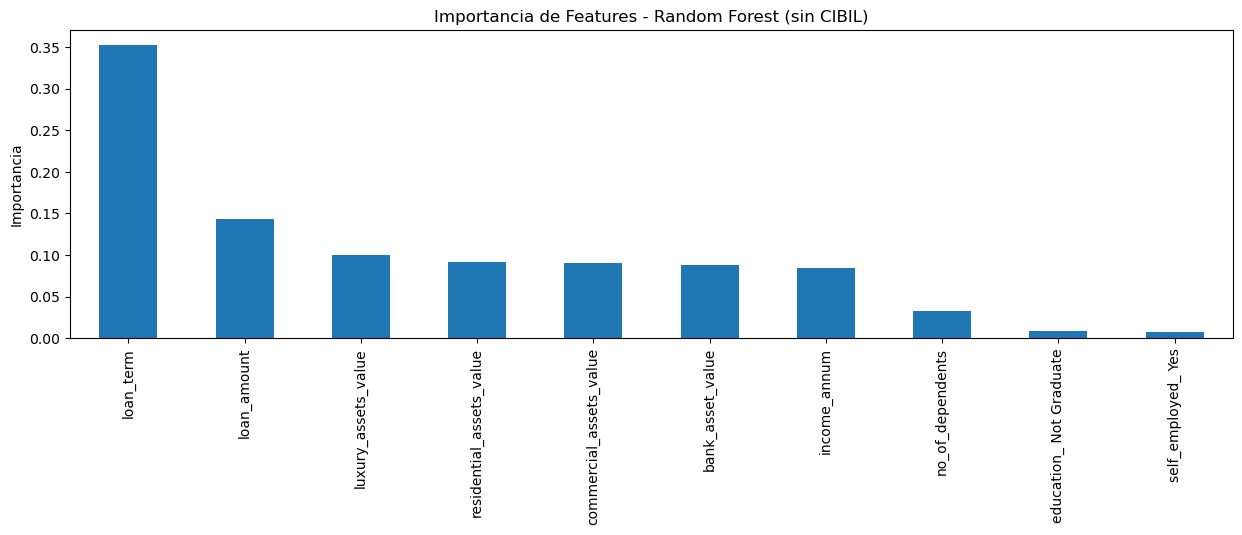

In [8]:
feature_importance_nc = pd.Series(
    rf_no_cibil.feature_importances_,
    index=X_no_cibil.columns
).sort_values(ascending=False)

plt.figure(figsize=(15,4))
feature_importance_nc.plot(kind='bar')
plt.title('Importancia de Features - Random Forest (sin CIBIL)')
plt.ylabel('Importancia')
plt.show()

**El modelo presenta una dependencia crítica del score crediticio. Al removerlo, el poder predictivo se degrada significativamente, lo que confirma que el score es una señal estructural del riesgo y no un artefacto del modelo.**

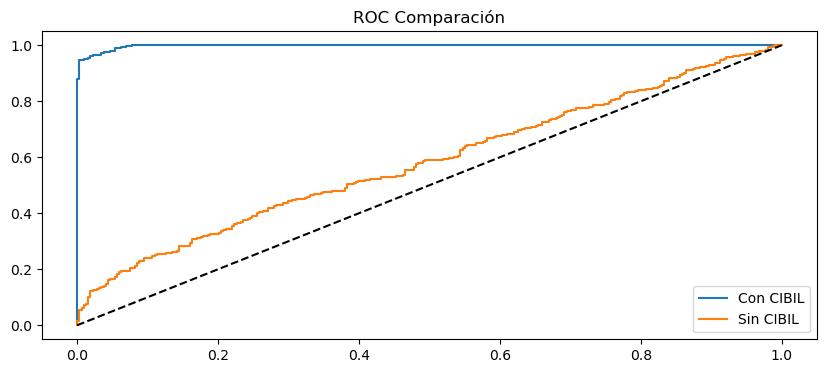

In [11]:
fpr1, tpr1, _ = roc_curve(y_test, y_prob_rf)
fpr2, tpr2, _ = roc_curve(y_test_nc, y_prob_rf_nc)

plt.figure(figsize=(10,4))
plt.plot(fpr1, tpr1, label='Con CIBIL')
plt.plot(fpr2, tpr2, label='Sin CIBIL')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Comparación")
plt.show()


### Comparación de Curvas ROC – Random Forest
La curva ROC evidencia una diferencia drástica en la capacidad de discriminación del modelo cuando se incluye el score crediticio (CIBIL) frente a cuando se lo elimina del conjunto de variables.

Con CIBIL, el modelo presenta una curva cercana al vértice superior izquierdo, con un ROC-AUC prácticamente perfecto, lo que indica una excelente capacidad para separar clientes confiables de clientes riesgosos.

En contraste, al remover el CIBIL score, la curva ROC se aproxima a la diagonal aleatoria, reflejando una pérdida significativa de poder predictivo y una discriminación apenas superior al azar.

Este resultado confirma que el score crediticio externo actúa como una señal estructural del riesgo y constituye el principal driver del desempeño del modelo.


In [12]:
import pickle

with open("../models/random_forest_no_cibil.pkl", "wb") as f:
    pickle.dump(rf_no_cibil, f)